# CAFÉ — one line, a full benchmark

> **The whole thesis of this library: one line of code runs a complete, publishable
> analysis.** No config, no fitting, no plumbing.

This notebook benchmarks CAFÉ's imputation against standard baselines and the published
state-of-the-art — with a single call, `cafe.benchmark(...)`.

**The honest framing up front.** Almost every published SOTA imputer (SAITS, BRITS, CSDI,
TimesNet, ImputeFormer, time-series foundation models) is **bidirectional**: to fill
`X[t]` it looks at the *whole window, including the future*. That's a smoothing task, and
in quantitative finance it's literally *forbidden look-ahead bias*
([Blanchet–Pelger 2022](https://arxiv.org/abs/2202.00871)). CAFÉ is **causal** — it fills
`X[t]` from data `≤ t` only, so it's backtest-safe by construction. The benchmark marks
every method `causal` or `bidir` and never pretends they're on equal footing. The
remarkable result: **CAFÉ matches or beats bidirectional SOTA while giving up the
future.**

## 0 · Setup

In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import cafe
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("CAFÉ", cafe.__version__)

CAFÉ 0.1.0


## 1 · The one-liner

`cafe.benchmark()` with no arguments runs on a self-contained synthetic dataset — CAFÉ
against five baselines, same held-out cells, same seed, scored identically. That's the
entire API.

In [2]:
cafe.benchmark()

CAFÉ benchmark — synthetic  (600×20, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.150    0.202   17.0%    0.10s ★
  LOCF                0.323    0.409   36.5%    0.00s
  Holt (lvl+tr)       0.434    0.542   49.0%    0.01s
  Kalman filter       0.610    0.768   69.0%    0.01s
  mean-of-past        0.881    1.103   99.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.159    0.209   18.0%    0.00s
  linear interp       0.237    0.302   26.8%    0.00s
  SVDImpute           0.249    0.443   28.1%    0.00s
  NOCB                0.325    0.411   36.7%    0.00s
  global mean         0.876    1.101   99.1%    0.00s

★ = best causal method.


CAFÉ benchmark — synthetic  (600×20, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.150    0.202   17.0%    0.10s ★
  LOCF                0.323    0.409   36.5%    0.00s
  Holt (lvl+tr)       0.434    0.542   49.0%    0.01s
  Kalman filter       0.610    0.768   69.0%    0.01s
  mean-of-past        0.881    1.103   99.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.159    0.209   18.0%    0.00s
  linear interp       0.237    0.302   26.8%    0.00s
  SVDImpute           0.249    0.443   28.1%    0.00s
  NOCB                0.325    0.411   36.7%    0.00s
  global mean         0.876    1.101   99.1%    0.00s

★ = best causal method.

The table is **grouped by kind** — causal methods first, bidirectional below — each block
sorted best-first. CAFÉ tops the causal block (★) and the whole table; the `global mean`
row is the **predict-the-mean trap** detector (anything near it has no real skill). Note
the baselines themselves are numpy-only, matching the library.

## 2 · The headline — real data, vs the published SOTA

`cafe.benchmark("beijing")` runs on **Beijing Multi-Site Air-Quality** (17,117 × 132) — the
dataset SAITS/CSDI/BRITS report on. Live baselines run here; the published deep-learning
numbers are a **clearly-labelled, single-source (TSI-Bench) reference**, not re-run.

**One honest caveat, stated up front:** the published numbers use the standard *windowed*
protocol (24-step windows). CAFÉ's row here imputes the **full series causally** — a
*different, strictly-online* setting. So this is not a like-for-like leaderboard; it shows
that CAFÉ's causal score lands *in the published bidirectional band*.

In [3]:
beijing = cafe.benchmark("beijing")

CAFÉ benchmark — beijing  (17117×132, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.114    0.356   14.8%    6.19s ★
  LOCF                0.202    0.502   26.2%    0.03s
  Holt (lvl+tr)       0.300    0.572   38.9%    0.25s
  Kalman filter       0.401    0.677   52.0%    0.22s
  mean-of-past        0.773    1.061  100.1%    0.03s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  linear interp       0.142    0.368   18.3%    0.03s
  SoftImpute          0.189    0.353   24.5%    0.40s
  NOCB                0.202    0.488   26.2%    0.03s
  SVDImpute           0.223    0.415   28.9%    0.39s
  global mean         0.768    1.061   99.6%    0.02s

PUBLISHED reference — BIDIRECTIONAL, windowed protocol [TSI-Bench (arXiv:2406.12747, preprint)].
  (Not run here. CAFÉ above runs th

**What this shows.** CAFÉ — *causal, numpy-only, ~7 s on one CPU core, no training* —
beats every **live** bidirectional baseline (linear interp, SoftImpute, SVDImpute, NOCB),
and its MAE (~0.114) lands *inside the published bidirectional band*: below TSI-Bench's own
SAITS (0.155), Transformer (0.142) and BRITS (0.127), with only the diffusion model CSDI
(0.102) and iTransformer (0.123) ahead — both of which **see the future**. CAFÉ is the
**only causal method in the comparison**. (Different protocol, so read it as "in the band,"
not a head-to-head win — see the caveat above.)

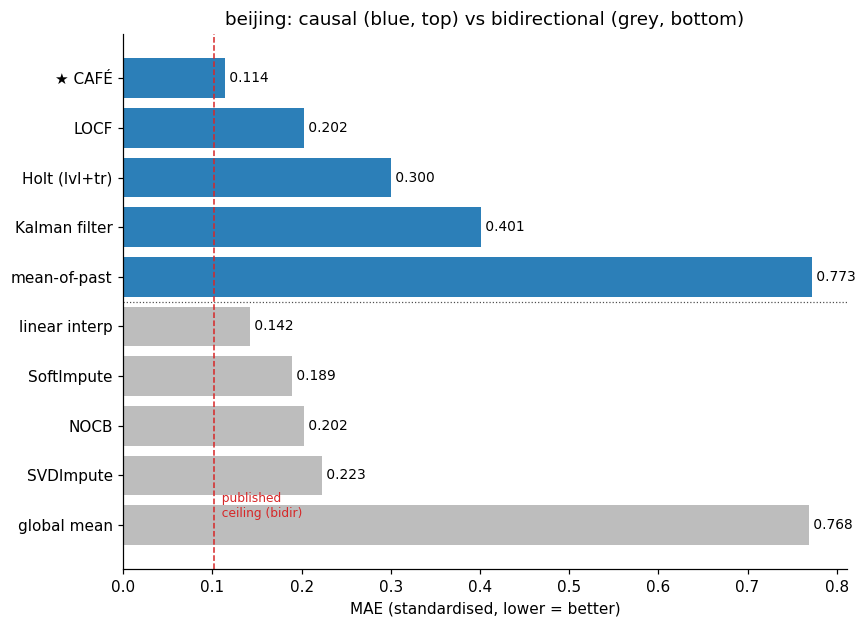

In [4]:
beijing.plot(); plt.tight_layout(); plt.show()

Blue = causal (top block), grey = bidirectional (below the dotted divider). The dashed red
line is the best *bidirectional* published score (CSDI 0.102) — the look-ahead ceiling.
CAFÉ sits just to its right while being the only backtest-safe option.

## 3 · The honest hard case — contiguous gaps

Scattered (MCAR) gaps are the easy case: a missing cell usually has observed neighbours in
its own row. The hard, realistic case is **block** missingness — a sensor goes dark for a
stretch. We don't hide from it; `pattern="block"` runs it. Causal methods can't borrow from
the future across a blackout, so the gap is genuinely harder for everyone — but CAFÉ's
factor + AR state still carries it.

In [5]:
cafe.benchmark("beijing", pattern="block", missing=0.1)

CAFÉ benchmark — beijing  (17117×132, 10% block missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.293    0.491   36.3%    6.11s ★
  mean-of-past        0.853    1.111  105.9%    0.03s
  Kalman filter       0.931    1.309  115.5%    0.20s
  LOCF                1.005    1.433  124.7%    0.02s
  Holt (lvl+tr)       1.247    1.744  154.7%    0.22s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.198    0.362   24.5%    0.49s
  SVDImpute           0.233    0.419   28.9%    1.03s
  linear interp       0.782    1.123   97.0%    0.02s
  global mean         0.831    1.089  103.1%    0.01s
  NOCB                0.952    1.341  118.2%    0.02s

PUBLISHED reference — BIDIRECTIONAL, windowed protocol [TSI-Bench (arXiv:2406.12747, preprint)].
  (Not run here. CAFÉ above runs t

CAFÉ benchmark — beijing  (17117×132, 10% block missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.293    0.491   36.3%    6.11s ★
  mean-of-past        0.853    1.111  105.9%    0.03s
  Kalman filter       0.931    1.309  115.5%    0.20s
  LOCF                1.005    1.433  124.7%    0.02s
  Holt (lvl+tr)       1.247    1.744  154.7%    0.22s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  SoftImpute          0.198    0.362   24.5%    0.49s
  SVDImpute           0.233    0.419   28.9%    1.03s
  linear interp       0.782    1.123   97.0%    0.02s
  global mean         0.831    1.089  103.1%    0.01s
  NOCB                0.952    1.341  118.2%    0.02s

PUBLISHED reference — BIDIRECTIONAL, windowed protocol [TSI-Bench (arXiv:2406.12747, preprint)].
  (Not run here. CAFÉ above runs t

## 4 · Breadth — another real dataset, one line

`cafe.benchmark("etth1")` on the Electricity Transformer Temperature set (17,420 × 7). No
published reference rows here (the public ETT imputation numbers use a different protocol,
so quoting them would be apples-to-oranges — we don't).

CAFÉ benchmark — etth1  (17420×7, 10% mcar missing, seed 0, standardised)

CAUSAL  (online / point-in-time, X[t] from data ≤ t — backtest-safe)
  method                MAE     RMSE     MRE     time
  CAFÉ                0.240    0.367   31.0%    2.76s ★
  LOCF                0.249    0.400   32.1%    0.00s
  Holt (lvl+tr)       0.365    0.582   47.2%    0.15s
  Kalman filter       0.457    0.681   59.1%    0.14s
  mean-of-past        0.747    1.004   96.6%    0.00s

BIDIRECTIONAL  (uses the whole series incl. the future — smoothing)
  method                MAE     RMSE     MRE     time
  linear interp       0.172    0.272   22.2%    0.00s
  NOCB                0.248    0.402   32.1%    0.00s
  SoftImpute          0.407    0.642   52.6%    0.02s
  SVDImpute           0.560    0.851   72.5%    0.03s
  global mean         0.753    1.006   97.4%    0.00s

★ = best causal method.


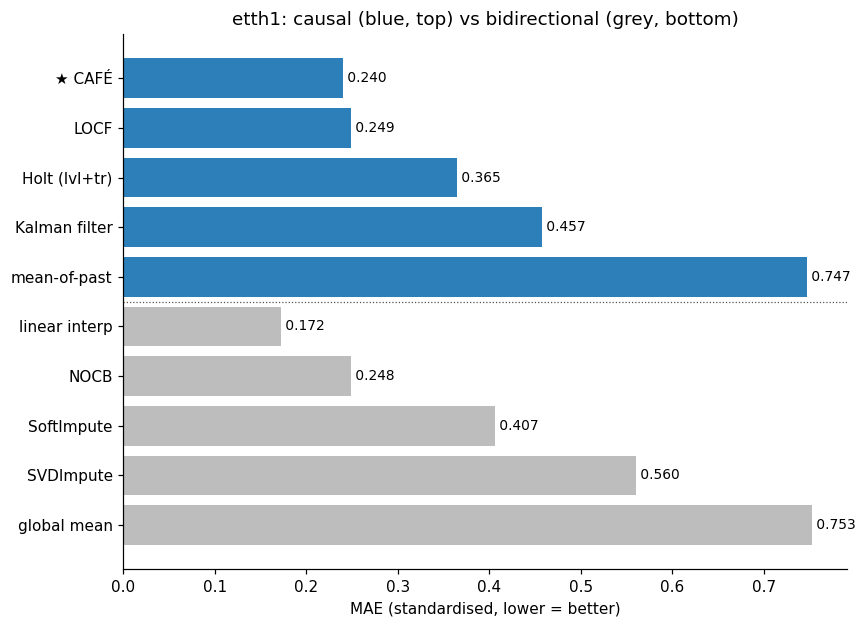

In [6]:
etth1 = cafe.benchmark("etth1", missing=0.1)
etth1.plot(); plt.tight_layout(); plt.show()

## 5 · It's the same one model behind everything

The benchmark imputer is the *same* `cafe.impute` you'd use in one line on your own data —
and the same forward pass yields uncertainty, factors, anomalies, a decomposition, a
dependency network and forecasts (see **`cafe_tutorial.ipynb`**). One model, every view of
its own posterior.

In [7]:
import numpy as np
X = np.load("../data/ETTh1_clean.npy")[:800]          # a real matrix
X[np.random.default_rng(0).random(X.shape) < 0.1] = np.nan
res = cafe.CAFE().run(X)
print("imputed:", np.asarray(res.imputed).shape,
      "| factors:", res.factors().shape,
      "| anomaly:", np.asarray(res.anomaly_scores()).shape,
      "| params:", res.params)

imputed: (800, 7) | factors: (800, 8) | anomaly: (800,) | params: {'nu': 5.327665336712613, 'ar': 0.8741362184269934, 'effective_rank': 2}


## Recap

| One line | What it does |
|---|---|
| `cafe.impute(df)` | fill gaps, any container, **no look-ahead** |
| `cafe.benchmark(df)` | CAFÉ vs baselines + cited SOTA, scored honestly |
| `cafe.benchmark("beijing")` | reproduce the headline: **causal CAFÉ ≈ bidirectional SOTA** |
| `cafe.CAFE().run(df)` | uncertainty, factors, anomalies, decomposition, network, forecast |

CAFÉ is **causal, CPU-only, zero-config**, and competitive with GPU-trained bidirectional
SOTA that has a structural look-ahead advantage — on the very benchmark those methods
report. That combination is, as of today, essentially unoccupied in the literature.

```bash
pip install cafe-impute
```